# Bayes' Theorem: A Biological Introduction

**Question:** If a cell expresses CD3, how should we update our belief that it is a T cell?

This notebook works through Bayes' theorem step by step using a simple biological example. We start with the prior, then add the likelihood and evidence to arrive at the posterior probability.

Along the way, we'll see how the prior can change the final probability, even when the observed evidence stays the same.

## 1. Prior probability — `P(T cell)` {Before Seeing the Evidence}
Before we look at any evidence, how common are T cells in the population of cells we're looking at?

This is the **prior**: what we believe before the new evidence (CD3 expression) arrives. In a typical PBMC (peripheral blood mononuclear cell) sample, T cells are a substantial but not overwhelming fraction — we'll use a representative estimate here.

In [1]:
# P(T cell): the prior probability that a randomly chosen cell is a T cell,
# before we've looked at any marker expression.
P_Tcell = 0.35

print(f"P(T cell) = {P_Tcell:.2f}")
print(f"P(not T cell) = {1 - P_Tcell:.2f}")

P(T cell) = 0.35
P(not T cell) = 0.65


## 2. Likelihood — `P(CD3 | T cell)` {How Likely Is the Evidence?}

The **likelihood** asks: *given* that a cell really is a T cell, how likely is it to show CD3 expression? We'll use an illustrative value of 0.95 here.

We also need the other side of the likelihood: if a cell is **not** a T cell, how likely is it to show CD3 expression? We'll use 0.08 as an illustrative false-positive probability.

These values are assumptions for the example, not measurements from a particular single-cell dataset.

In [4]:
# P(CD3 | T cell): sensitivity - probability a true T cell expresses CD3
P_CD3_given_Tcell = 0.95

# P(CD3 | not T cell): false positive rate - probability a non-T cell
# still shows CD3 signal (ambient RNA, doublets, related lymphocyte subsets)
P_CD3_given_notTcell = 0.08

print(f"P(CD3 | T cell)     = {P_CD3_given_Tcell:.2f}")
print(f"P(CD3 | not T cell) = {P_CD3_given_notTcell:.2f}")

P(CD3 | T cell)     = 0.95
P(CD3 | not T cell) = 0.08


## 3. Evidence — `P(CD3)` {Overall Evidence}

Before we can compute the posterior, we need to know the overall probability of observing CD3 expression **at all**, across every cell in the population — T cell or not.

This is the **law of total probability**: a cell can express CD3 via two disjoint routes — being a T cell and expressing it, or not being a T cell and expressing it anyway. Summing both gives the total evidence.

$$
P(CD3) = P(CD3 \mid \text{T cell})\cdot P(\text{T cell})
+ P(CD3 \mid \neg\text{T cell})\cdot P(\neg\text{T cell})
$$

In [5]:
P_notTcell = 1 - P_Tcell

P_CD3 = (P_CD3_given_Tcell * P_Tcell) + (P_CD3_given_notTcell * P_notTcell)

print(f"P(CD3) = {P_CD3_given_Tcell:.2f} × {P_Tcell:.2f}  +  {P_CD3_given_notTcell:.2f} × {P_notTcell:.2f}")
print(f"P(CD3) = {P_CD3:.4f}")

P(CD3) = 0.95 × 0.35  +  0.08 × 0.65
P(CD3) = 0.3845


## 4. Posterior — `P(T cell | CD3)` {After Seeing the Evidence}

Now we can answer the actual question: **given that a cell expresses CD3, what's the probability it's a T cell?**

This is the posterior — our updated belief after seeing the evidence.

In [6]:
P_Tcell_given_CD3 = (P_CD3_given_Tcell * P_Tcell) / P_CD3

print(f"P(T cell | CD3) = {P_Tcell_given_CD3:.4f}")
print(f"\nBefore seeing CD3: P(T cell) = {P_Tcell:.2f}")
print(f"After seeing CD3:  P(T cell | CD3) = {P_Tcell_given_CD3:.2f}")

P(T cell | CD3) = 0.8648

Before seeing CD3: P(T cell) = 0.35
After seeing CD3:  P(T cell | CD3) = 0.86


## 5. Bayes' theorem

What we just calculated can be written formally using Bayes' theorem:

$$
P(\text{T cell} \mid CD3)
=
\frac{P(\text{T cell})\cdot P(CD3 \mid \text{T cell})}
{P(CD3)}
$$

In words:

**Posterior = Prior × Likelihood / Evidence**

In our example, seeing CD3 increases the probability that the cell is a T cell — from 35% before seeing CD3 to about 86% after seeing it.

But it does not reach 100%. Strong evidence can increase our confidence, but it does not guarantee the answer.

In our example, CD3 makes us much more confident that the cell is a T cell, but CD3 alone does not prove that it is a T cell.

> **Important:** Bayes' theorem does not create probabilities from nothing. The quality of the posterior depends on the prior and likelihoods used as inputs.

## 6. A numerical example — Step by Step

Let's use an imagined population of 1,000 cells and apply the same probabilities as counts. This is the same calculation as above, but expressed with actual numbers.

In [7]:
n_cells = 1000

n_Tcell = round(n_cells * P_Tcell)
n_notTcell = n_cells - n_Tcell

n_Tcell_CD3pos = round(n_Tcell * P_CD3_given_Tcell)
n_notTcell_CD3pos = round(n_notTcell * P_CD3_given_notTcell)

n_CD3pos_total = n_Tcell_CD3pos + n_notTcell_CD3pos

print(f"Out of {n_cells} cells:")
print(f"  {n_Tcell} are T cells, of which {n_Tcell_CD3pos} express CD3")
print(f"  {n_notTcell} are not T cells, of which {n_notTcell_CD3pos} express CD3 anyway")
print(f"\n  Total CD3-positive cells: {n_CD3pos_total}")
print(f"  Of those, {n_Tcell_CD3pos} are genuinely T cells")
print(f"\n  P(T cell | CD3) = {n_Tcell_CD3pos} / {n_CD3pos_total} = {n_Tcell_CD3pos/n_CD3pos_total:.4f}")

Out of 1000 cells:
  350 are T cells, of which 332 express CD3
  650 are not T cells, of which 52 express CD3 anyway

  Total CD3-positive cells: 384
  Of those, 332 are genuinely T cells

  P(T cell | CD3) = 332 / 384 = 0.8646


- `n_cells` → total number of cells = **1,000**
- `P_Tcell` → prior probability of a T cell = **0.35 (35%)**
- `n_Tcell` → expected number of T cells = **350**

* Same answer, two ways: counting cells or applying the formula.

## 7. Simulation in Python

Now let's simulate a large population of cells and see whether the result approaches the probability we calculated above.

We'll first assign each cell a true identity based on the prior, then simulate CD3 expression based on the likelihoods. Finally, we'll calculate the posterior from the simulated cells and compare it with the theoretical result.

In [8]:
import numpy as np

rng = np.random.default_rng(seed=7)
n_sim = 200_000

# Step 1: assign true cell identity according to the prior
is_Tcell = rng.random(n_sim) < P_Tcell

# Step 2: simulate CD3 expression according to the relevant likelihood
p_cd3 = np.where(is_Tcell, P_CD3_given_Tcell, P_CD3_given_notTcell)
expresses_CD3 = rng.random(n_sim) < p_cd3

# Step 3: among CD3-positive cells, what fraction are genuinely T cells?
empirical_posterior = is_Tcell[expresses_CD3].mean()

print(f"Theoretical P(T cell | CD3) = {P_Tcell_given_CD3:.4f}")
print(f"Empirical P(T cell | CD3)   = {empirical_posterior:.4f}")
print(f"(from {expresses_CD3.sum():,} simulated CD3-positive cells out of {n_sim:,})")

Theoretical P(T cell | CD3) = 0.8648
Empirical P(T cell | CD3)   = 0.8644
(from 76,933 simulated CD3-positive cells out of 200,000)


The simulated result (0.8644) is very close to the theoretical result (0.8648), showing that the simulation reproduces the Bayesian calculation.

## 8. Visualizing prior vs. posterior

A single bar chart makes the update from step 4 visible: how far did seeing CD3 move our belief?

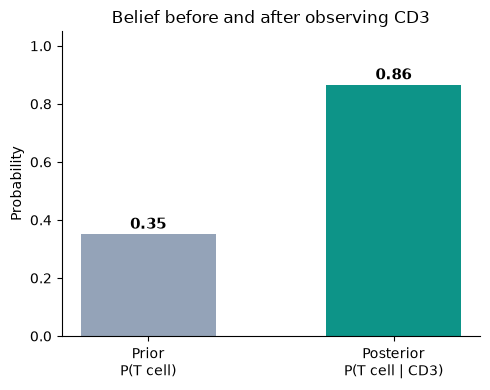

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["Prior\nP(T cell)", "Posterior\nP(T cell | CD3)"],
    [P_Tcell, P_Tcell_given_CD3],
    color=["#94A3B8", "#0D9488"],
    width=0.55,
)

for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width()/2,
        h + 0.02,
        f"{h:.2f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_ylim(0, 1.05)
ax.set_ylabel("Probability")
ax.set_title("Belief before and after observing CD3")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

fig.savefig(
    "/media/nikhil/My_Book/Git_repo/Bayes_for_Bioinfo/results/prior_vs_posterior.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. What happens when the prior changes?

This is the part that matters most for single-cell annotation. So far we fixed the prior at 35%. But what if the cell type we're looking for is rare — say, only 2% of the population?

Let's change the prior from very rare to very common and see how the posterior changes.

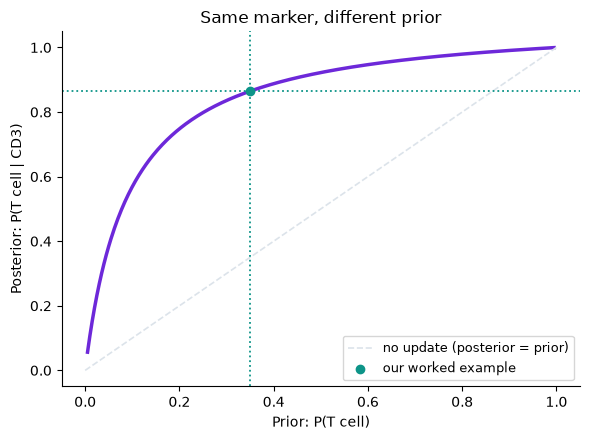

In [13]:
priors = np.linspace(0.005, 0.995, 400)
posteriors = (P_CD3_given_Tcell * priors) / (
    P_CD3_given_Tcell * priors + P_CD3_given_notTcell * (1 - priors)
)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(priors, posteriors, color="#6D28D9", linewidth=2.5)
ax.plot([0, 1], [0, 1], color="#DCE3EA", linestyle="--", linewidth=1.2, label="no update (posterior = prior)")

ax.axvline(P_Tcell, color="#0D9488", linestyle=":", linewidth=1.3)
ax.axhline(P_Tcell_given_CD3, color="#0D9488", linestyle=":", linewidth=1.3)
ax.scatter([P_Tcell], [P_Tcell_given_CD3], color="#0D9488", zorder=5, label="our worked example")

ax.set_xlabel("Prior: P(T cell)")
ax.set_ylabel("Posterior: P(T cell | CD3)")
ax.set_title("Same marker, different prior")
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(
    "/media/nikhil/My_Book/Git_repo/Bayes_for_Bioinfo/results/prior_sweep.png",
    dpi=300
)

plt.show()

### Reading the curve

Two things are worth noticing:

- **When the prior is very low** (a rare cell type), the posterior stays surprisingly low even with a strong, specific marker. A 95%-sensitive, 8%-false-positive marker applied to a cell type that's genuinely only 2% of the population still leaves substantial uncertainty — most of the "positive" cells are false positives, simply because there are so many more non-target cells to draw them from.

- **When the prior is already high**, the same evidence pushes the posterior much closer to certainty because there is less competing probability mass.

This is why single-marker annotation can be risky for rare populations: the same observed evidence can lead to different posterior beliefs depending on the starting prevalence. Reference-based annotation methods use broader expression patterns rather than relying on a single marker in isolation. 
Later in this repo, we'll also examine how LLM-based annotation behaves when the available evidence is limited.